🔍 Procurando dados em: c:\Users\Raphael Okuyama\Desktop\projeto-tcc\apps\ml\data\processed\metropt3.parquet
✅ Dataset carregado com sucesso: 500000 linhas.
⚙️ Aplicando Engenharia de Features...
✅ Features geradas. Colunas atuais: 39
⚖️ Aplicando balanceamento SMOTE...
✅ Balanceamento concluído!
📊 Distribuição Original: {0: 441448, 1: 58552}
📊 Distribuição Balanceada: {0: 441448, 1: 441448}
🕵️ Colunas encontradas para TP2: ['TP2_delta', 'TP2_std_5', 'TP2_ma_5', 'TP2_ma_15']


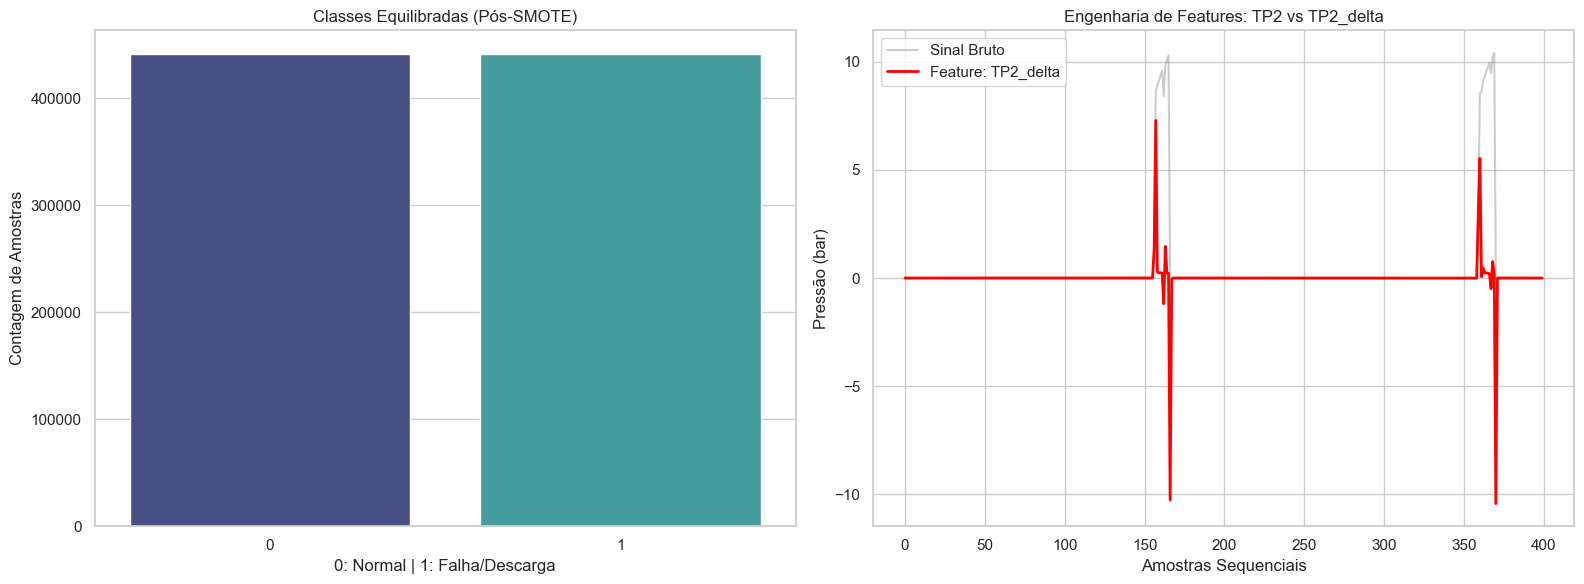

In [5]:
# ---------------------------------------------------------------------------
# 1. SETUP DE AMBIENTE E CAMINHOS
# ---------------------------------------------------------------------------
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Adiciona a pasta 'apps/ml' ao path para encontrar o módulo 'src'
current_path = Path(os.getcwd())
if (current_path / "src").exists():
    sys.path.append(str(current_path))
elif (current_path.parent / "src").exists():
    sys.path.append(str(current_path.parent))

from src.preprocessing import MetroPTPreprocessor
from src.balancing import MetroPTBalancer

# Configuração visual
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [15, 6]

# ---------------------------------------------------------------------------
# 2. CARREGAMENTO DOS DADOS (INGESTÃO)
# ---------------------------------------------------------------------------
PARQUET_PATH = Path("data/processed/metropt3.parquet")

if not PARQUET_PATH.exists():
    PARQUET_PATH = Path("../data/processed/metropt3.parquet")

print(f"🔍 Procurando dados em: {PARQUET_PATH.absolute()}")

if not PARQUET_PATH.exists():
    raise FileNotFoundError("❌ Arquivo Parquet não encontrado! Rode o script 'ingest_metropt.py' antes.")

# Dataset limitado para visualização rápida e leve
df_raw = pd.read_parquet(PARQUET_PATH).iloc[:500000]
print(f"✅ Dataset carregado com sucesso: {df_raw.shape[0]} linhas.")

# ---------------------------------------------------------------------------
# 3. ENGENHARIA DE FEATURES (PREPROCESSING)
# ---------------------------------------------------------------------------
y_raw = (df_raw['COMP'] < 0.5).astype(int)

print("⚙️ Aplicando Engenharia de Features...")
preprocessor = MetroPTPreprocessor()
df_features = preprocessor.fit_transform(df_raw)

print(f"✅ Features geradas. Colunas atuais: {len(df_features.columns)}")

# ---------------------------------------------------------------------------
# 4. BALANCEAMENTO DE CLASSES (SMOTE)
# ---------------------------------------------------------------------------
print("⚖️ Aplicando balanceamento SMOTE...")
X = df_features.drop(columns=['timestamp'])

balancer = MetroPTBalancer()
X_resampled, y_resampled = balancer.fit_resample(X, y_raw)

print(f"✅ Balanceamento concluído!")
print(f"📊 Distribuição Original: {pd.Series(y_raw).value_counts().to_dict()}")
print(f"📊 Distribuição Balanceada: {pd.Series(y_resampled).value_counts().to_dict()}")

# ---------------------------------------------------------------------------
# 5. VISUALIZAÇÃO DE RESULTADOS (COM DETECÇÃO AUTOMÁTICA)
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Equilíbrio de Classes
sns.countplot(x=y_resampled, ax=ax1, hue=y_resampled, palette='mako', legend=False)
ax1.set_title("Classes Equilibradas (Pós-SMOTE)")
ax1.set_xlabel("0: Normal | 1: Falha/Descarga")
ax1.set_ylabel("Contagem de Amostras")

# Gráfico B: Efeito da Engenharia de Features (Buscando o nome real)
sensor = 'TP2'

# Busca todas as colunas que têm "TP2" no nome, mas que NÃO sejam o próprio "TP2"
colunas_derivadas = [c for c in df_features.columns if sensor in c and c != sensor]

print(f"🕵️ Colunas encontradas para {sensor}: {colunas_derivadas}")

if colunas_derivadas:
    # Pega a primeira coluna gerada (ex: a média móvel ou desvio padrão)
    feature_col = colunas_derivadas[0] 
    
    amostra_plot = df_features.iloc[1000:1400].reset_index()
    
    # Plota o Sinal Bruto
    ax2.plot(amostra_plot.index, amostra_plot[sensor], label='Sinal Bruto', alpha=0.4, color='gray')
    
    # Plota a Feature Filtrada
    ax2.plot(amostra_plot.index, amostra_plot[feature_col], label=f'Feature: {feature_col}', color='red', linewidth=2)
    
    ax2.set_title(f"Engenharia de Features: {sensor} vs {feature_col}")
    ax2.set_ylabel("Pressão (bar)")
    ax2.set_xlabel("Amostras Sequenciais")
    ax2.legend()
else:
    print(f"⚠️ Nenhuma feature extra encontrada para o sensor {sensor}.")

plt.tight_layout()
plt.show()